Calculating motion vectors via SAD... please wait.


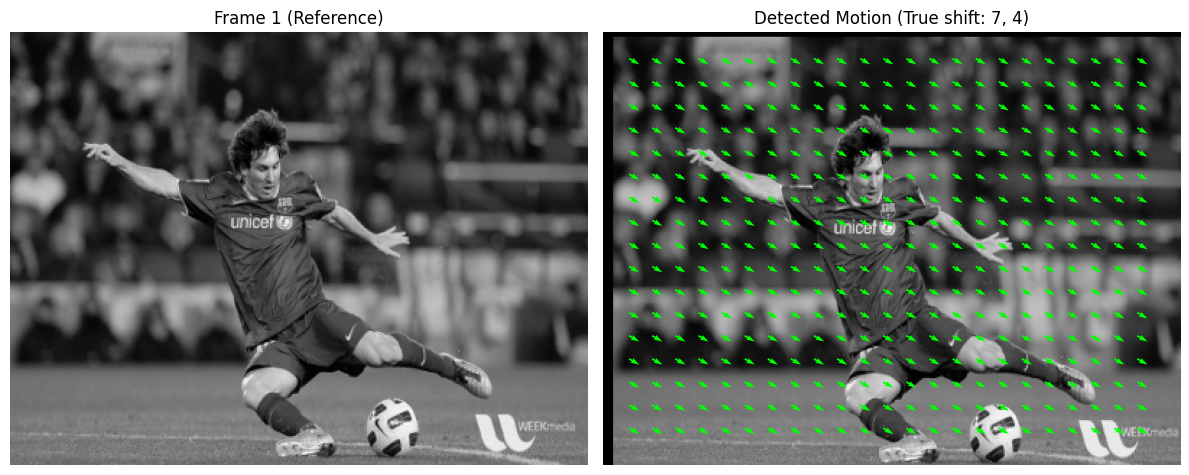

Analysis Complete.
Mean detected motion: dx=7.00, dy=4.00


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

# 1. Download a reliable image (OpenCV sample data)
def get_reliable_image():
    filename = "input_image.png"
    # Using a standard OpenCV sample image from GitHub
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg"
    
    if not os.path.exists(filename):
        print("Downloading test image...")
        try:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            with open(filename, 'wb') as f:
                f.write(r.content)
        except Exception as e:
            print(f"Download failed: {e}. Creating a procedural pattern instead.")
            # Fallback: Create a grid pattern if internet is down
            img = np.zeros((300, 300), dtype=np.uint8)
            for i in range(0, 300, 30): cv2.line(img, (i, 0), (i, 300), 255, 2)
            for j in range(0, 300, 30): cv2.line(img, (0, j), (300, j), 255, 2)
            cv2.imwrite(filename, img)
    return filename

# 2. Setup Images (Source and Synthetically Shifted)
img_path = get_reliable_image()
base_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
base_img = cv2.resize(base_img, (400, 300)) # Resize for speed

# Create Frame 2 by shifting Frame 1 (dx=7, dy=4)
dx_true, dy_true = 7, 4
rows, cols = base_img.shape
M = np.float32([[1, 0, dx_true], [0, 1, dy_true]])
shifted_img = cv2.warpAffine(base_img, M, (cols, rows))

# 3. SAD Block Matching Algorithm
def block_matching_sad(img1, img2, block_size=16, search_range=10):
    h, w = img1.shape
    half = block_size // 2
    
    px, py, dx_list, dy_list = [], [], [], []

    # Iterate through the image in steps of block_size
    for i in range(search_range, h - block_size - search_range, block_size):
        for j in range(search_range, w - block_size - search_range, block_size):
            # Reference block in the current frame
            ref_block = img1[i:i+block_size, j:j+block_size].astype(np.int32)
            
            min_sad = float('inf')
            best_match = (0, 0)

            # Search in the second frame within range
            for dy in range(-search_range, search_range + 1):
                for dx in range(-search_range, search_range + 1):
                    target_block = img2[i+dy:i+dy+block_size, j+dx:j+dx+block_size].astype(np.int32)
                    
                    # Sum of Absolute Differences
                    sad = np.sum(np.abs(ref_block - target_block))
                    
                    if sad < min_sad:
                        min_sad = sad
                        best_match = (dx, dy)
            
            px.append(j + half)
            py.append(i + half)
            dx_list.append(best_match[0])
            dy_list.append(best_match[1])
            
    return px, py, dx_list, dy_list

# 4. Execute and Visualize
print("Calculating motion vectors via SAD... please wait.")
px, py, dx, dy = block_matching_sad(base_img, shifted_img)



plt.figure(figsize=(12, 6))

# Show Frame 1
plt.subplot(1, 2, 1)
plt.imshow(base_img, cmap='gray')
plt.title("Frame 1 (Reference)")
plt.axis('off')

# Show Frame 2 with Motion Vectors
plt.subplot(1, 2, 2)
plt.imshow(shifted_img, cmap='gray')
plt.quiver(px, py, dx, dy, color='lime', angles='xy', scale_units='xy', scale=1)
plt.title(f"Detected Motion (True shift: {dx_true}, {dy_true})")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Analysis Complete.")
print(f"Mean detected motion: dx={np.mean(dx):.2f}, dy={np.mean(dy):.2f}")